In [1]:
import pandas as pd
df = pd.read_csv('Pictures/Clustering_gmm.csv')
df.head()

,Weight,Height
0,67.062924,176.086355
1,68.804094,178.388669
2,60.930863,170.284496
3,59.733843,168.691992
4,65.431230,173.763679


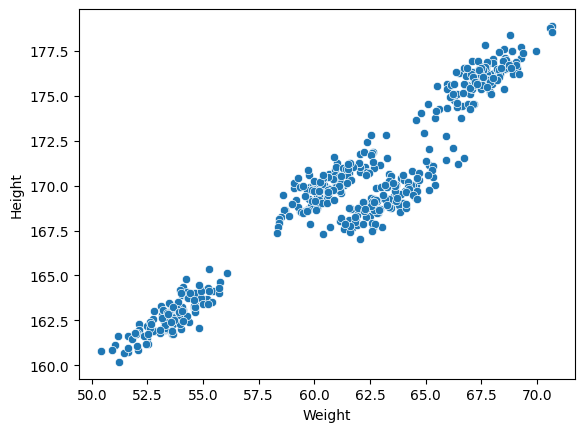

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x = df['Weight'] , y = df['Height'])
plt.show()

In [3]:
x = df.copy()

## Training the DBSCAN model

In this step, I initialized the **DBSCAN** clustering model and trained it on the selected dataset.

DBSCAN groups data points based on **density**, unlike K-Means which relies on centroids and a predefined number of clusters.  
To configure the model, I used:

- **`eps = 0.5`** → the maximum distance between two points for them to be considered neighbors  
- **`min_samples = 5`** → the minimum number of nearby points required for a point to be treated as a core point and form part of a dense region

After defining the model, I applied `fit()` to train DBSCAN on the dataset and allow it to identify dense groups of points as clusters, while also detecting isolated points as noise.

In [4]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps = 0.5 , min_samples = 5)
db.fit(x)

,eps,0.5
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [5]:
db.labels_

array([ 0, -1,  1,  1, -1,  2,  2,  1,  1,  3,  2,  0,  2,  3,  1,  1,  0,
        1,  3,  1,  1,  0,  2,  3,  1,  3,  0,  2,  3,  2,  2,  2,  0,  2,
        2, -1,  3,  1,  3,  0,  3, -1,  1,  0,  2,  0,  1,  1,  0,  0,  3,
        3, -1,  1,  4,  2,  2,  3,  3,  0,  0,  3,  0,  0,  0,  2,  1,  0,
        1,  2,  3,  1,  3,  0,  3,  0,  2,  2,  1,  1,  3,  1,  3,  1,  1,
        2,  3,  3,  0,  3,  3,  3,  0,  3,  1,  1,  0, -1,  0,  1,  3,  3,
        0,  3,  1,  4,  2,  0,  1,  3,  3,  2,  3,  3,  0,  3,  0,  1, -1,
        0,  1,  3,  0,  0,  3,  0,  0,  0,  0,  3,  1,  3,  2,  3,  3,  3,
        1,  0,  1,  2, -1,  0,  0,  0,  2,  3,  1,  1,  2,  3, -1,  0,  1,
        1,  4,  2,  2,  0,  2,  1,  0,  1,  0, -1,  2,  2, -1,  1,  3,  2,
        0,  3,  0,  2,  1,  3,  1,  3,  3,  3, -1,  0, -1,  1,  2,  3,  2,
        0,  2,  3,  0,  2,  3,  2,  2,  3,  1,  2,  1,  3,  3,  1,  2,  2,
        1,  2,  2,  4,  2, -1,  2,  0, -1,  0,  1, -1,  2,  3,  3,  3,  1,
        0,  2,  3,  2,  0

In [6]:
x['clusters'] = db.labels_

In [7]:
x

,Weight,Height,clusters
0,67.062924,176.086355,0
1,68.804094,178.388669,-1
2,60.930863,170.284496,1
3,59.733843,168.691992,1
4,65.431230,173.763679,-1
...,...,...,...
495,59.976983,169.679741,1
496,66.423814,174.625574,0
497,53.604698,161.919208,3
498,50.433644,160.794875,-1


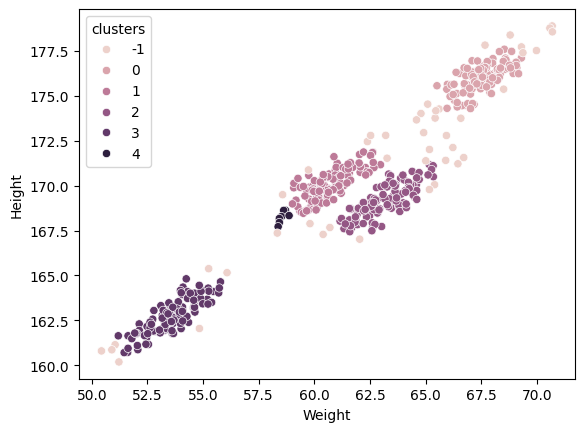

In [8]:
sns.scatterplot(x = x['Weight'] , y = x['Height'] , hue = x['clusters'] )
plt.show()

## Evaluating DBSCAN using Silhouette Score


In [9]:
from sklearn.metrics import silhouette_score
silhouette_score(df , x['clusters'])
# .25 : .5 usable
# 0 : .25 weak model
# .5 : perfect

0.47848985974513664

## DBSCAN model improvement

In [16]:
db2 = DBSCAN(eps = 0.65 , min_samples = 6)
db2.fit(df)

,eps,0.65
,min_samples,6
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [11]:
db2.labels_

array([ 0, -1,  1,  1, -1,  2,  2,  1,  1,  3,  2,  0,  2,  3,  1,  1,  0,
        1,  3,  1,  1,  0,  2,  3,  1,  3,  0,  2,  3,  2,  2,  2,  0,  2,
        2, -1,  3,  1,  3,  0,  3,  1,  1,  0,  2,  0,  1,  1,  0,  0,  3,
        3, -1,  1,  1,  2,  2,  3,  3,  0,  0,  3,  0,  0,  0,  2,  1,  0,
        1,  2,  3,  1,  3,  0,  3,  0,  2,  2,  1,  1,  3,  1,  3,  1,  1,
        2,  3,  3,  0,  3,  3,  3,  0,  3,  1,  1,  0,  0,  0,  1,  3,  3,
        0,  3,  1,  1,  2,  0,  1,  3,  3,  2,  3,  3,  0,  3,  0,  1,  2,
        0,  1,  3,  0,  0,  3,  0,  0,  0,  0,  3,  1,  3,  2,  3,  3,  3,
        1,  0,  1,  2, -1,  0,  0,  0,  2,  3,  1,  1,  2,  3, -1,  0,  1,
        1,  1,  2,  2,  0,  2,  1,  0,  1,  0,  0,  2,  2, -1,  1,  3,  2,
        0,  3,  0,  2,  1,  3,  1,  3,  3,  3,  0,  0, -1,  1,  2,  3,  2,
        0,  2,  3,  0,  2,  3,  2,  2,  3,  1,  2,  1,  3,  3,  1,  2,  2,
        1,  2,  2,  1,  2, -1,  2,  0, -1,  0,  1,  0,  2,  3,  3,  3,  1,
        0,  2,  3,  2,  0

In [12]:
x['clusters2'] = db2.labels_

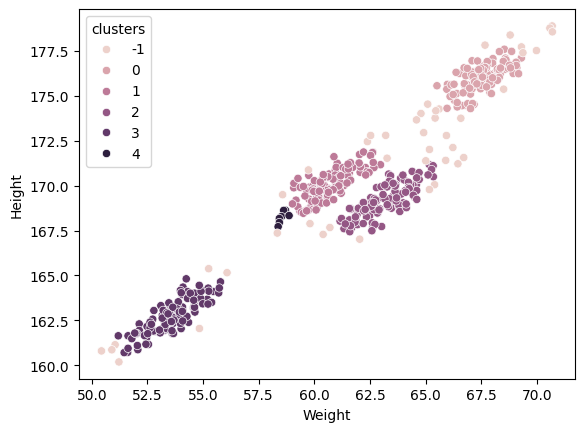

In [13]:
sns.scatterplot(x = x['Weight'] , y = x['Height'] , hue = x['clusters'] )
plt.show()

In [14]:
from sklearn.metrics import silhouette_score
silhouette_score(df , x['clusters2'])

0.564092595223784